# Participation-Weighted Fair Value

Extension of the research notebook. Generates all publication figures and trains a GRU to show the count-based signal combines with temporal modelling.

Requires GPU runtime for the GRU section.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install polars scipy scikit-learn -q

Mounted at /content/drive


In [2]:
import numpy as np
import polars as pl
from scipy import stats
from sklearn.linear_model import Ridge
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings, time, gc

matplotlib.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif',
})
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

DATA_DIR = Path('/content/drive/MyDrive/lob_fairvalue/data')
OUT_DIR = Path('/content/drive/MyDrive/lob_fairvalue/outputs')
OUT_DIR.mkdir(exist_ok=True)

WARMUP = 2000
CLIP = 5.0

Device: cuda


## 1. Load Data (same as research notebook)

In [3]:
def load_equity(path):
    name = path.stem
    try:
        df = pl.read_parquet(path)
    except:
        return None
    if 'trade_date' not in df.columns or 'bid_price_1' not in df.columns:
        return None
    df = df.with_columns(
        pl.col('exchange_timestamp').dt.hour().alias('hour'),
        pl.col('exchange_timestamp').dt.minute().alias('minute'),
    )
    df = df.filter(
        ((pl.col('hour') == 9) & (pl.col('minute') >= 15))
        | ((pl.col('hour') >= 10) & (pl.col('hour') <= 14))
        | ((pl.col('hour') == 15) & (pl.col('minute') <= 30))
    )
    df = df.filter(
        (pl.col('bid_price_1') > 0) & (pl.col('ask_price_1') > 0)
        & (pl.col('ask_price_1') > pl.col('bid_price_1'))
    )
    n = len(df)
    if n < 5000:
        return None
    out = {'name': name, 'n': n, 'type': 'equity'}
    for side in ['bid', 'ask']:
        for field in ['price', 'qty', 'orders']:
            key = f'{side}_{field}'
            out[key] = np.column_stack([
                df[f'{side}_{field}_{i}'].to_numpy().astype(np.float64) for i in range(1, 6)
            ])
    out['mid'] = (out['bid_price'][:, 0] + out['ask_price'][:, 0]) / 2.0
    out['spread_bps'] = (out['ask_price'][:, 0] - out['bid_price'][:, 0]) / out['mid'] * 10000
    out['dates'] = np.array(df['trade_date'].to_list())
    out['days'] = sorted(set(out['dates'].tolist()))
    lp = df['last_price'].to_numpy().astype(np.float64)
    vol_raw = df['volume'].to_numpy().astype(np.float64)
    out['tick_vol'] = np.clip(np.diff(vol_raw, prepend=vol_raw[0]), 0, None)
    out['trade_sign'] = np.zeros(n)
    out['trade_sign'][lp >= out['ask_price'][:, 0]] = 1.0
    out['trade_sign'][lp <= out['bid_price'][:, 0]] = -1.0
    return out

equity_files = sorted([p for p in DATA_DIR.glob('*.parquet') if p.stem != 'index_futures'])
t0 = time.time()
all_stocks = []
for i, path in enumerate(equity_files):
    r = load_equity(path)
    if r is not None:
        all_stocks.append(r)
    if (i + 1) % 40 == 0:
        print(f'  {i+1}/{len(equity_files)} ({time.time()-t0:.0f}s)')
print(f'Loaded: {len(all_stocks)} equities ({time.time()-t0:.0f}s)')

  40/183 (25s)
  80/183 (30s)
  120/183 (38s)
  160/183 (46s)
Loaded: 183 equities (50s)


## Figure 1: Level-by-Level IC Decay

IC of order book imbalance at each depth level vs forward return, across all equities on test days.

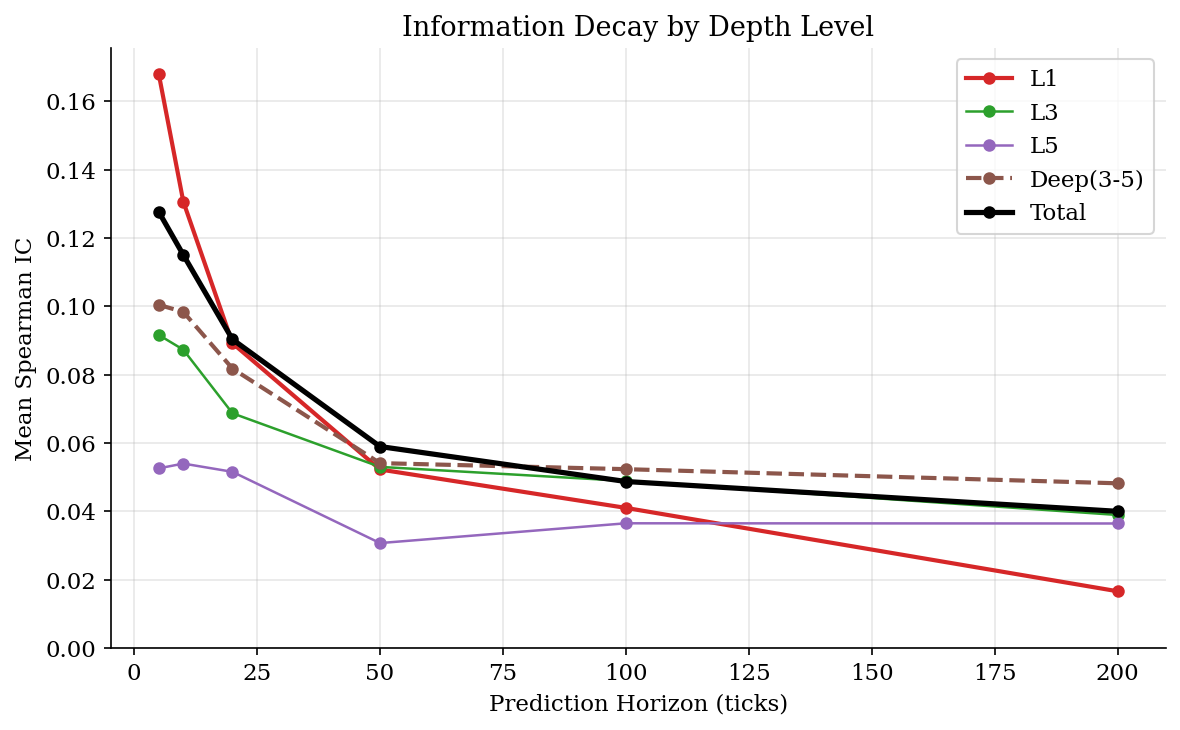

Saved fig1_level_decay


In [4]:
HORIZONS_DECAY = [5, 10, 20, 50, 100, 200]

level_ics = {f'L{l+1}': {h: [] for h in HORIZONS_DECAY} for l in range(5)}
level_ics['Deep(3-5)'] = {h: [] for h in HORIZONS_DECAY}
level_ics['Total'] = {h: [] for h in HORIZONS_DECAY}

for s in all_stocks:
    if len(s['days']) < 4:
        continue
    test_days = s['days'][3:]
    n, mid, dates = s['n'], s['mid'], s['dates']
    bq, aq = s['bid_qty'], s['ask_qty']

    obi_levels = np.zeros((n, 5))
    for l in range(5):
        obi_levels[:, l] = (bq[:, l] - aq[:, l]) / (bq[:, l] + aq[:, l] + 1e-9)

    obi_deep = np.mean(obi_levels[:, 2:5], axis=1)
    tb = bq.sum(axis=1) + 1e-9
    ta = aq.sum(axis=1) + 1e-9
    obi_total = (tb - ta) / (tb + ta + 1e-9)

    test_mask = np.isin(dates, test_days)
    test_mask[:WARMUP] = False

    for h in HORIZONS_DECAY:
        fwd = np.full(n, np.nan)
        fwd[:n-h] = (mid[h:] - mid[:n-h]) / mid[:n-h] * 10000
        valid = test_mask & np.isfinite(fwd)
        indices = np.where(valid)[0][::h]
        if len(indices) < 50:
            continue
        fr = fwd[indices]
        for l in range(5):
            ic = stats.spearmanr(obi_levels[indices, l], fr).statistic
            if np.isfinite(ic):
                level_ics[f'L{l+1}'][h].append(ic)
        ic_d = stats.spearmanr(obi_deep[indices], fr).statistic
        if np.isfinite(ic_d):
            level_ics['Deep(3-5)'][h].append(ic_d)
        ic_t = stats.spearmanr(obi_total[indices], fr).statistic
        if np.isfinite(ic_t):
            level_ics['Total'][h].append(ic_t)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'L1': '#d62728', 'L2': '#ff7f0e', 'L3': '#2ca02c', 'L4': '#1f77b4', 'L5': '#9467bd',
          'Deep(3-5)': '#8c564b', 'Total': '#000000'}
linestyles = {'L1': '-', 'L2': '-', 'L3': '-', 'L4': '-', 'L5': '-',
              'Deep(3-5)': '--', 'Total': '-'}
linewidths = {'L1': 2, 'L2': 1.2, 'L3': 1.2, 'L4': 1.2, 'L5': 1.2,
              'Deep(3-5)': 2, 'Total': 2.5}

for key in ['L1', 'L3', 'L5', 'Deep(3-5)', 'Total']:
    ys = [np.mean(level_ics[key][h]) if level_ics[key][h] else np.nan for h in HORIZONS_DECAY]
    ax.plot(HORIZONS_DECAY, ys, marker='o', markersize=5, color=colors[key],
            linestyle=linestyles[key], linewidth=linewidths[key], label=key)

ax.set_xlabel('Prediction Horizon (ticks)')
ax.set_ylabel('Mean Spearman IC')
ax.set_title('Information Decay by Depth Level')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_level_decay.png', dpi=200, bbox_inches='tight')
plt.savefig(OUT_DIR / 'fig1_level_decay.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_level_decay')

## Figure 2: Fair Value IC Comparison

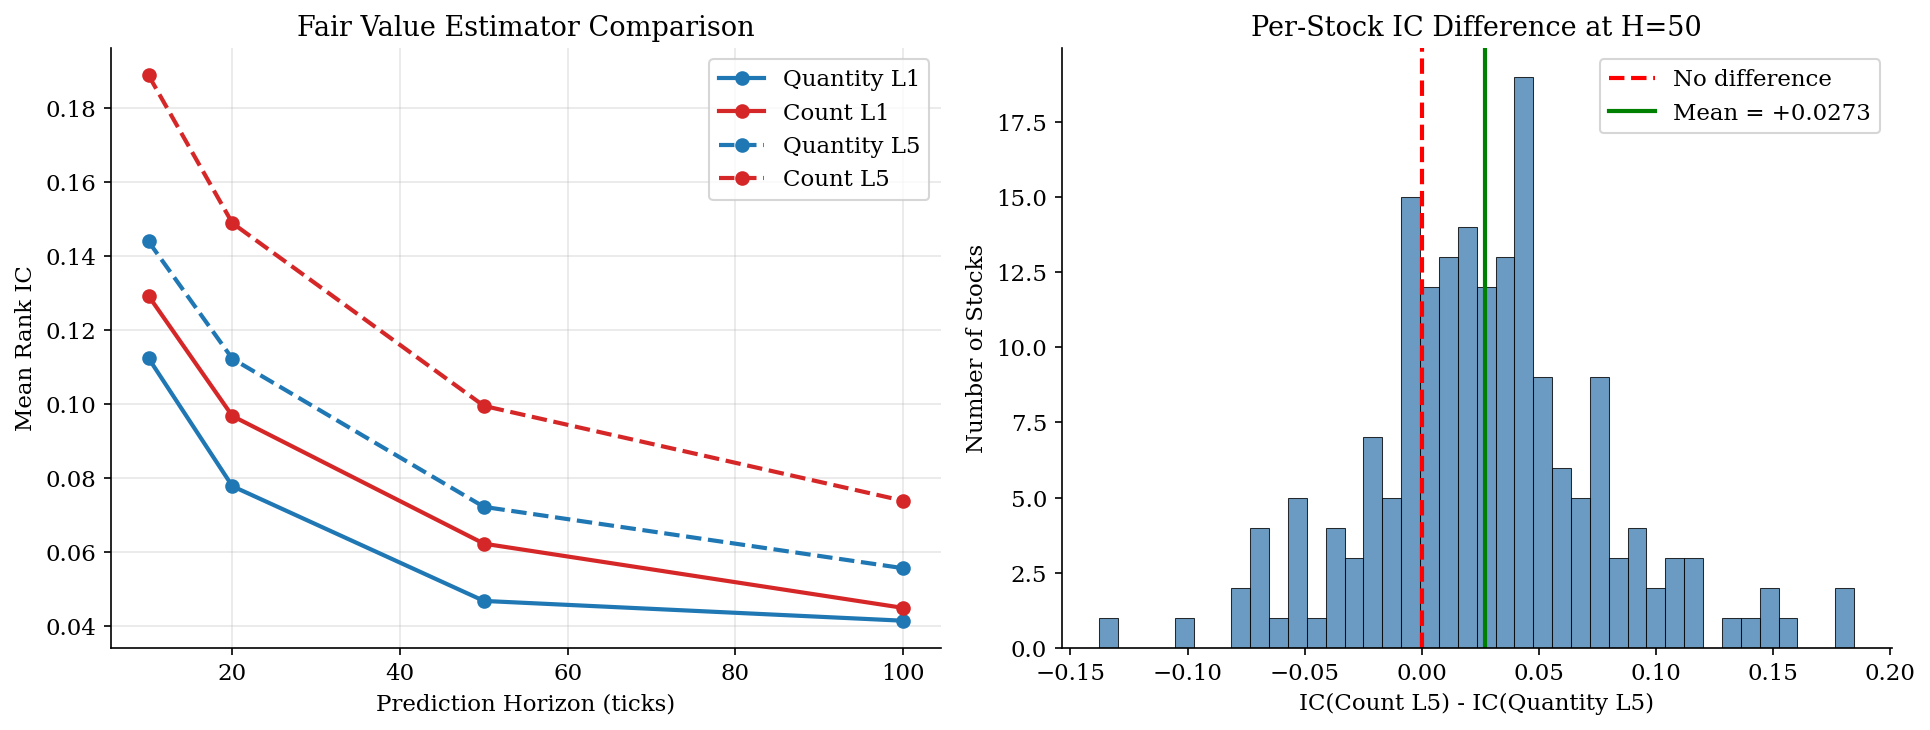

Saved fig2_fv_comparison


In [5]:
HORIZONS_FV = [10, 20, 50, 100]

def compute_fv(s):
    n = s['n']
    bp, ap = s['bid_price'], s['ask_price']
    bq, aq = s['bid_qty'], s['ask_qty']
    bn, an = s['bid_orders'], s['ask_orders']
    fvs = {}
    fvs['qty_L1'] = (bp[:,0]*aq[:,0] + ap[:,0]*bq[:,0]) / (bq[:,0]+aq[:,0]+1e-9)
    fvs['cnt_L1'] = (bp[:,0]*an[:,0] + ap[:,0]*bn[:,0]) / (bn[:,0]+an[:,0]+1e-9)
    lam = 0.5
    w = np.array([np.exp(-lam*i) for i in range(5)]); w /= w.sum()
    for tag, wt_fn in [('qty_L5', lambda i: (aq[:,i], bq[:,i])),
                        ('cnt_L5', lambda i: (an[:,i], bn[:,i]))]:
        num = np.zeros(n); den = np.zeros(n)
        for i in range(5):
            wa, wb = wt_fn(i)
            num += w[i]*(bp[:,i]*wa + ap[:,i]*wb)
            den += w[i]*(wa+wb)
        fvs[tag] = num / (den+1e-9)
    return fvs

fv_ics = {fn: {h: [] for h in HORIZONS_FV} for fn in ['qty_L1','cnt_L1','qty_L5','cnt_L5']}

for s in all_stocks:
    if len(s['days']) < 4:
        continue
    test_days = s['days'][3:]
    fvs = compute_fv(s)
    n, mid, dates = s['n'], s['mid'], s['dates']
    test_mask = np.isin(dates, test_days)
    test_mask[:WARMUP] = False
    for h in HORIZONS_FV:
        future_mid = np.full(n, np.nan)
        future_mid[:n-h] = mid[h:]
        valid = test_mask & np.isfinite(future_mid)
        indices = np.where(valid)[0][::h]
        if len(indices) < 50:
            continue
        fm = future_mid[indices]; m = mid[indices]; fwd = fm - m
        for fn in fv_ics:
            disp = fvs[fn][indices] - m
            mask = np.abs(disp) > 1e-9
            if mask.sum() > 50:
                ic = stats.spearmanr(disp[mask], fwd[mask]).statistic
                if np.isfinite(ic):
                    fv_ics[fn][h].append(ic)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
plot_fns = [('qty_L1', '#1f77b4', '-', 'Quantity L1'),
            ('cnt_L1', '#d62728', '-', 'Count L1'),
            ('qty_L5', '#1f77b4', '--', 'Quantity L5'),
            ('cnt_L5', '#d62728', '--', 'Count L5')]
for fn, col, ls, label in plot_fns:
    ys = [np.mean(fv_ics[fn][h]) for h in HORIZONS_FV]
    ax.plot(HORIZONS_FV, ys, marker='o', color=col, linestyle=ls, linewidth=2, label=label)
ax.set_xlabel('Prediction Horizon (ticks)')
ax.set_ylabel('Mean Rank IC')
ax.set_title('Fair Value Estimator Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
h = 50
iq = np.array(fv_ics['qty_L5'][h])
ic = np.array(fv_ics['cnt_L5'][h])
n_plot = min(len(iq), len(ic))
diff = ic[:n_plot] - iq[:n_plot]
ax.hist(diff, bins=40, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label='No difference')
ax.axvline(x=np.mean(diff), color='green', linewidth=2, label=f'Mean = {np.mean(diff):+.4f}')
ax.set_xlabel('IC(Count L5) - IC(Quantity L5)')
ax.set_ylabel('Number of Stocks')
ax.set_title(f'Per-Stock IC Difference at H={h}')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_fv_comparison.png', dpi=200, bbox_inches='tight')
plt.savefig(OUT_DIR / 'fig2_fv_comparison.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_fv_comparison')

## Figure 3: Cross-Sectional Decile Analysis

Building stock lookups for cross-sectional analysis...
Reference: HDFCBANK (42624 ticks), 673 snapshots


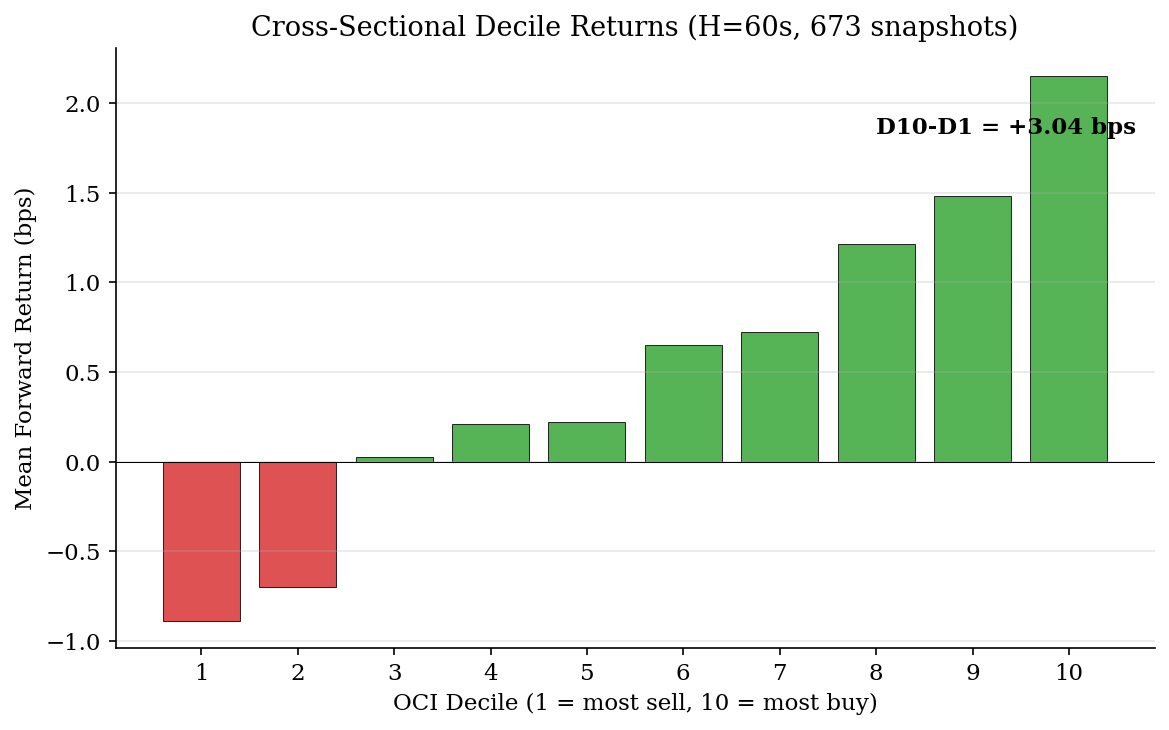

Saved fig3_decile


In [6]:
def causal_rolling_zscore(x, lookback=2000, clip=5.0):
    n = len(x)
    out = np.full(n, np.nan)
    xc = np.where(np.isfinite(x), x, 0.0)
    iv = np.isfinite(x).astype(np.float64)
    cs = np.cumsum(xc); cs2 = np.cumsum(xc**2); cn = np.cumsum(iv)
    for i in range(lookback, n):
        j = i - lookback
        count = cn[i-1] - cn[j]
        if count < lookback * 0.5:
            continue
        s = cs[i-1] - cs[j]; s2 = cs2[i-1] - cs2[j]
        mean = s / count; var = s2/count - mean**2
        if var <= 0:
            out[i] = 0.0
        else:
            out[i] = (x[i] - mean) / np.sqrt(var)
    return np.clip(out, -clip, clip)

print('Building stock lookups for cross-sectional analysis...')
stock_lookup = {}
for s in all_stocks:
    if len(s['days']) < 4:
        continue
    test_days = s['days'][3:]
    mask = np.isin(s['dates'], test_days)
    if mask.sum() < 500:
        continue
    bn, an = s['bid_orders'], s['ask_orders']
    tb_n = bn.sum(axis=1) + 1e-9
    ta_n = an.sum(axis=1) + 1e-9
    oci = (tb_n - ta_n) / (tb_n + ta_n + 1e-9)
    oci_z = causal_rolling_zscore(oci)
    oci_z = np.where(np.isfinite(oci_z), oci_z, 0.0)
    ts_ns = s['dates']  # placeholder, using tick index
    stock_lookup[s['name']] = {
        'mid': s['mid'][mask], 'oci_z': oci_z[mask], 'n': mask.sum()
    }

ref_name = max(stock_lookup, key=lambda k: stock_lookup[k]['n'])
ref_n = stock_lookup[ref_name]['n']
snap_indices = list(range(WARMUP, ref_n - 300, 60))
print(f'Reference: {ref_name} ({ref_n} ticks), {len(snap_indices)} snapshots')

H_CS = 60
decile_rets = [[] for _ in range(10)]

for snap_idx in snap_indices:
    signals = []
    fwd_rets = []
    for sname, sd in stock_lookup.items():
        if snap_idx >= sd['n'] or snap_idx + H_CS >= sd['n']:
            continue
        sig = sd['oci_z'][snap_idx]
        mid_now = sd['mid'][snap_idx]
        mid_fut = sd['mid'][snap_idx + H_CS]
        if mid_now <= 0:
            continue
        ret = (mid_fut - mid_now) / mid_now * 10000
        if np.isfinite(sig) and np.isfinite(ret):
            signals.append(sig)
            fwd_rets.append(ret)

    if len(signals) < 50:
        continue
    signals = np.array(signals)
    fwd_rets = np.array(fwd_rets)
    n_s = len(signals)
    dec_size = n_s // 10
    rank = np.argsort(signals)
    for d in range(10):
        start = d * dec_size
        end = (d+1) * dec_size if d < 9 else n_s
        decile_rets[d].append(np.mean(fwd_rets[rank[start:end]]))

fig, ax = plt.subplots(figsize=(8, 5))
means = [np.mean(dr) for dr in decile_rets]
colors_dec = ['#d62728' if m < 0 else '#2ca02c' for m in means]
bars = ax.bar(range(1, 11), means, color=colors_dec, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('OCI Decile (1 = most sell, 10 = most buy)')
ax.set_ylabel('Mean Forward Return (bps)')
ax.set_title(f'Cross-Sectional Decile Returns (H={H_CS}s, {len(snap_indices)} snapshots)')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3, axis='y')

d10d1 = means[-1] - means[0]
ax.annotate(f'D10-D1 = {d10d1:+.2f} bps', xy=(8, max(means)*0.85),
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_decile.png', dpi=200, bbox_inches='tight')
plt.savefig(OUT_DIR / 'fig3_decile.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_decile')

## Figure 4: Signed Count Flow vs Volume Flow

In [ ]:
WINDOWS_FLOW = [10, 20, 30, 50, 75, 100, 150, 200]
H_FLOW = 50

ic_vol = {w: [] for w in WINDOWS_FLOW}
ic_cnt = {w: [] for w in WINDOWS_FLOW}

for s in all_stocks:
    if len(s['days']) < 4:
        continue
    test_days = s['days'][3:]
    n, mid, dates = s['n'], s['mid'], s['dates']
    test_mask = np.isin(dates, test_days)
    test_mask[:WARMUP] = False
    fwd = np.full(n, np.nan)
    fwd[:n-H_FLOW] = (mid[H_FLOW:] - mid[:n-H_FLOW]) / mid[:n-H_FLOW] * 10000
    valid_base = test_mask & np.isfinite(fwd)

    for W in WINDOWS_FLOW:
        vol_flow = np.convolve(s['trade_sign'] * s['tick_vol'], np.ones(W), mode='same')
        cnt_flow = np.convolve(s['trade_sign'], np.ones(W), mode='same')
        vol_z = causal_rolling_zscore(vol_flow)
        vol_z = np.where(np.isfinite(vol_z), vol_z, 0.0)
        cnt_z = causal_rolling_zscore(cnt_flow)
        cnt_z = np.where(np.isfinite(cnt_z), cnt_z, 0.0)

        indices = np.where(valid_base)[0][::H_FLOW]
        if len(indices) > 50:
            ic_v = stats.spearmanr(vol_z[indices], fwd[indices]).statistic
            ic_c = stats.spearmanr(cnt_z[indices], fwd[indices]).statistic
            if np.isfinite(ic_v):
                ic_vol[W].append(ic_v)
            if np.isfinite(ic_c):
                ic_cnt[W].append(ic_c)

fig, ax = plt.subplots(figsize=(8, 5))
ys_vol = [np.mean(ic_vol[w]) for w in WINDOWS_FLOW]
ys_cnt = [np.mean(ic_cnt[w]) for w in WINDOWS_FLOW]
ax.plot(WINDOWS_FLOW, ys_vol, marker='s', color='#1f77b4', linewidth=2, label='Signed Volume Flow')
ax.plot(WINDOWS_FLOW, ys_cnt, marker='o', color='#d62728', linewidth=2, label='Signed Count Flow')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(WINDOWS_FLOW, 0, ys_cnt, alpha=0.1, color='#d62728')
ax.fill_between(WINDOWS_FLOW, ys_vol, 0, alpha=0.1, color='#1f77b4')
ax.set_xlabel('Accumulation Window (ticks)')
ax.set_ylabel('Mean IC vs Forward Return')
ax.set_title('Signed Flow')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_signed_flow.png', dpi=200, bbox_inches='tight')
plt.savefig(OUT_DIR / 'fig4_signed_flow.pdf', bbox_inches='tight')
plt.show()
print('Saved fig4_signed_flow')

## GRU: Count-Based Features Enhance Temporal Prediction

We train two GRUs on identical architecture, differing only in feature set:
1. 17 standard LOB features (quantity-based OBI, spread, depth, etc.)
2. 23 features adding order flow signals (order count imbalance, cumulative signed count, depth deltas, trade intensity)

*I used a GRU to test whether temporal dynamics in the order book add information beyond the static snapshot, due to its hidden state.*

In [8]:
HORIZON = 50
SEQ_LEN = 20
N_ORIG = 17

def compute_features(s):
    n = s['n']
    bq, aq = s['bid_qty'], s['ask_qty']
    bp, ap = s['bid_price'], s['ask_price']
    bn, an = s['bid_orders'], s['ask_orders']
    mid = s['mid']
    spread = s['spread_bps']
    tv = s['tick_vol']
    ts_arr = s['trade_sign']
    tb = bq.sum(axis=1)+1e-9; ta = aq.sum(axis=1)+1e-9

    feats = []

    feats.append(spread)
    obi_l1 = (bq[:,0]-aq[:,0])/(bq[:,0]+aq[:,0]+1e-9)
    feats.append(obi_l1)
    feats.append((tb-ta)/(tb+ta+1e-9))
    obi_l5 = (bq[:,4]-aq[:,4])/(bq[:,4]+aq[:,4]+1e-9)
    feats.append(obi_l1 - obi_l5)
    mp = (bp[:,0]*aq[:,0]+ap[:,0]*bq[:,0])/(bq[:,0]+aq[:,0]+1e-9)
    feats.append((mp-mid)/mid*10000)
    feats.append(bq[:,0]/tb)
    feats.append(aq[:,0]/ta)
    bf=(bq[:,0]+bq[:,1])/2+1; bb=(bq[:,3]+bq[:,4])/2+1
    af=(aq[:,0]+aq[:,1])/2+1; ab_v=(aq[:,3]+aq[:,4])/2+1
    feats.append(np.log((bb+ab_v)/(bf+af)))
    oc = bn[:,0]+an[:,0]
    feats.append((bq[:,0]+aq[:,0])/(oc+1e-9))
    od5=np.zeros(n); od5[5:]=obi_l1[5:]-obi_l1[:-5]
    feats.append(od5)
    od20=np.zeros(n); od20[20:]=obi_l1[20:]-obi_l1[:-20]
    feats.append(od20)
    sd=np.zeros(n); sd[1:]=spread[1:]-spread[:-1]
    feats.append(np.convolve(sd, np.ones(5)/5, mode='same'))
    bm=np.ones(n); am=np.ones(n)
    for i in range(10,n): bm[i]=np.max(bq[i-10:i,0]); am[i]=np.max(aq[i-10:i,0])
    feats.append(bq[:,0]/(bm+1e-9))
    feats.append(aq[:,0]/(am+1e-9))
    td=tb+ta; dc=np.zeros(n); dc[5:]=td[5:]-td[:-5]
    feats.append(dc)
    feats.append(tv)
    feats.append(ts_arr)

    signed_vol = ts_arr * tv
    feats.append(np.convolve(signed_vol, np.ones(20), mode='same'))
    feats.append(np.convolve(signed_vol, np.ones(100), mode='same'))
    bid_d = np.zeros(n); bid_d[1:] = bq[1:,0]-bq[:-1,0]
    ask_d = np.zeros(n); ask_d[1:] = aq[1:,0]-aq[:-1,0]
    feats.append(np.convolve(bid_d, np.ones(10)/10, mode='same'))
    feats.append(np.convolve(ask_d, np.ones(10)/10, mode='same'))
    feats.append(np.convolve((tv>0).astype(np.float64), np.ones(20), mode='same'))
    tb_n = bn.sum(axis=1); ta_n = an.sum(axis=1)
    feats.append((tb_n-ta_n)/(tb_n+ta_n+1e-9))

    raw = np.column_stack(feats)
    X = np.full_like(raw, np.nan)
    for j in range(raw.shape[1]):
        X[:, j] = causal_rolling_zscore(raw[:, j])
    X = np.where(np.isfinite(X), X, 0.0)
    return X

def build_dataset(stocks, split):
    Xseq_list, y_list = [], []
    for s in stocks:
        if len(s['days']) < 4:
            continue
        if split == 'train': sd = s['days'][:2]
        elif split == 'val': sd = [s['days'][2]]
        else: sd = s['days'][3:]

        X = compute_features(s)
        n, mid, dates = s['n'], s['mid'], s['dates']
        target = np.full(n, np.nan)
        target[:n-HORIZON] = (mid[HORIZON:]-mid[:n-HORIZON])/mid[:n-HORIZON]*10000

        mask = np.isin(dates, sd) & np.all(np.isfinite(X), axis=1) & np.isfinite(target)
        mask[:max(SEQ_LEN, WARMUP)] = False
        indices = np.where(mask)[0][::HORIZON]
        if len(indices) < 10:
            continue
        Xs = np.zeros((len(indices), SEQ_LEN, X.shape[1]), dtype=np.float32)
        y = np.zeros(len(indices), dtype=np.float32)
        for k, idx in enumerate(indices):
            Xs[k] = X[idx-SEQ_LEN+1:idx+1].astype(np.float32)
            y[k] = target[idx]
        Xseq_list.append(Xs)
        y_list.append(y)

    return np.concatenate(Xseq_list), np.concatenate(y_list)

print('Building datasets...')
Xtr, ytr = build_dataset(all_stocks, 'train')
Xva, yva = build_dataset(all_stocks, 'val')
Xte, yte = build_dataset(all_stocks, 'test')
print(f'Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}')
N_FEATS = Xtr.shape[2]
print(f'Features: {N_FEATS} (first {N_ORIG} original, rest order flow)')

Building datasets...
Train: (101307, 20, 23)  Val: (48051, 20, 23)  Test: (67861, 20, 23)
Features: 23 (first 17 original, rest order flow)


In [9]:
class GRU(nn.Module):
    def __init__(self, input_dim, hidden=64, n_layers=2, dropout=0.15):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, n_layers, batch_first=True,
                          dropout=dropout if n_layers > 1 else 0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        h = self.drop(h_n[-1])
        return self.head(h).squeeze(-1)


def rank_ic(sig, tgt):
    v = np.isfinite(sig) & np.isfinite(tgt)
    if v.sum() < 50:
        return np.nan
    return stats.spearmanr(sig[v], tgt[v]).statistic


def train_gru(Xtr, ytr, Xva, yva, n_feats, epochs=35, lr=5e-4, batch_size=512, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = GRU(n_feats).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/10)
    criterion = nn.MSELoss()
    ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    history = {'epoch': [], 'train_loss': [], 'val_ic': []}
    best_ic = -1; best_state = None

    for ep in range(epochs):
        model.train()
        ep_loss = 0; nb = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item(); nb += 1
        sched.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for start in range(0, len(Xva), 4096):
                batch = torch.from_numpy(Xva[start:start+4096]).to(device)
                preds.append(model(batch).cpu().numpy())
        val_pred = np.concatenate(preds)
        val_ic = rank_ic(val_pred, yva)

        history['epoch'].append(ep+1)
        history['train_loss'].append(ep_loss/nb)
        history['val_ic'].append(val_ic)

        if val_ic > best_ic:
            best_ic = val_ic
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (ep+1) % 5 == 0:
            print(f'  Ep {ep+1}: loss={ep_loss/nb:.4f} val_IC={val_ic:+.4f} (best={best_ic:+.4f})')

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    return model, history


def eval_gru(model, X, y):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X), 4096):
            batch = torch.from_numpy(X[start:start+4096]).to(device)
            preds.append(model(batch).cpu().numpy())
    pred = np.concatenate(preds)
    ic = rank_ic(pred, y)
    da = np.mean((pred > 0) == (y > 0))
    di = np.argsort(pred); ds = len(pred)//10
    d10d1 = np.mean(y[di[-ds:]]) - np.mean(y[di[:ds]])
    return {'ic': round(ic,4), 'acc': round(da,4), 'd10d1': round(d10d1,3), 'pred': pred}

In [10]:
print('=== GRU: 23 features (original + order flow) ===')
gru_full, hist_full = train_gru(Xtr, ytr, Xva, yva, N_FEATS)
r_full = eval_gru(gru_full, Xte, yte)
print(f'  Test: IC={r_full["ic"]:+.4f} acc={r_full["acc"]:.4f} D10-D1={r_full["d10d1"]:+.3f}')

print(f'\n=== GRU: 17 features (original only) ===')
gru_orig, hist_orig = train_gru(Xtr[:,:,:N_ORIG], ytr, Xva[:,:,:N_ORIG], yva, N_ORIG)
r_orig = eval_gru(gru_orig, Xte[:,:,:N_ORIG], yte)
print(f'  Test: IC={r_orig["ic"]:+.4f} acc={r_orig["acc"]:.4f} D10-D1={r_orig["d10d1"]:+.3f}')

print(f'\n=== Ridge baselines ===')
Xf_tr = Xtr[:, -1, :]; Xf_va = Xva[:, -1, :]; Xf_te = Xte[:, -1, :]
ridge_full = Ridge(alpha=10.0); ridge_full.fit(Xf_tr, ytr)
ridge_orig = Ridge(alpha=10.0); ridge_orig.fit(Xf_tr[:,:N_ORIG], ytr)

r_rf = rank_ic(ridge_full.predict(Xf_te), yte)
r_ro = rank_ic(ridge_orig.predict(Xf_te[:,:N_ORIG]), yte)

print(f'  Ridge (17 orig):     IC={r_ro:+.4f}')
print(f'  Ridge (23 +flow):    IC={r_rf:+.4f}')

print(f'\n{"="*50}')
print(f'COMPARISON')
print(f'{"="*50}')
print(f'  {"Model":>22s} {"IC":>8s} {"Acc":>8s} {"D10-D1":>8s}')
print(f'  {"-"*50}')
print(f'  {"Ridge (17)":>22s} {r_ro:>+8.4f} {"":>8s} {"":>8s}')
print(f'  {"Ridge (23)":>22s} {r_rf:>+8.4f} {"":>8s} {"":>8s}')
print(f'  {"GRU (17)":>22s} {r_orig["ic"]:>+8.4f} {r_orig["acc"]:>8.4f} {r_orig["d10d1"]:>+8.3f}')
print(f'  {"GRU (23)":>22s} {r_full["ic"]:>+8.4f} {r_full["acc"]:>8.4f} {r_full["d10d1"]:>+8.3f}')

=== GRU: 23 features (original + order flow) ===
  Ep 5: loss=194.4612 val_IC=+0.1086 (best=+0.1110)
  Ep 10: loss=194.3724 val_IC=+0.1132 (best=+0.1132)
  Ep 15: loss=192.0432 val_IC=+0.1088 (best=+0.1133)
  Ep 20: loss=190.3618 val_IC=+0.1012 (best=+0.1133)
  Ep 25: loss=188.3972 val_IC=+0.0975 (best=+0.1133)
  Ep 30: loss=183.6827 val_IC=+0.0977 (best=+0.1133)
  Ep 35: loss=186.3956 val_IC=+0.0929 (best=+0.1133)
  Test: IC=+0.0872 acc=0.5325 D10-D1=+1.640

=== GRU: 17 features (original only) ===
  Ep 5: loss=195.7578 val_IC=+0.0807 (best=+0.0842)
  Ep 10: loss=194.7357 val_IC=+0.0857 (best=+0.0882)
  Ep 15: loss=193.0855 val_IC=+0.0857 (best=+0.0882)
  Ep 20: loss=192.2660 val_IC=+0.0830 (best=+0.0882)
  Ep 25: loss=189.6287 val_IC=+0.0812 (best=+0.0882)
  Ep 30: loss=190.2123 val_IC=+0.0822 (best=+0.0882)
  Ep 35: loss=189.4983 val_IC=+0.0805 (best=+0.0882)
  Test: IC=+0.0763 acc=0.5322 D10-D1=+1.496

=== Ridge baselines ===
  Ridge (17 orig):     IC=+0.0641
  Ridge (23 +flow):   

## Figure 5: GRU Training and IC Progression

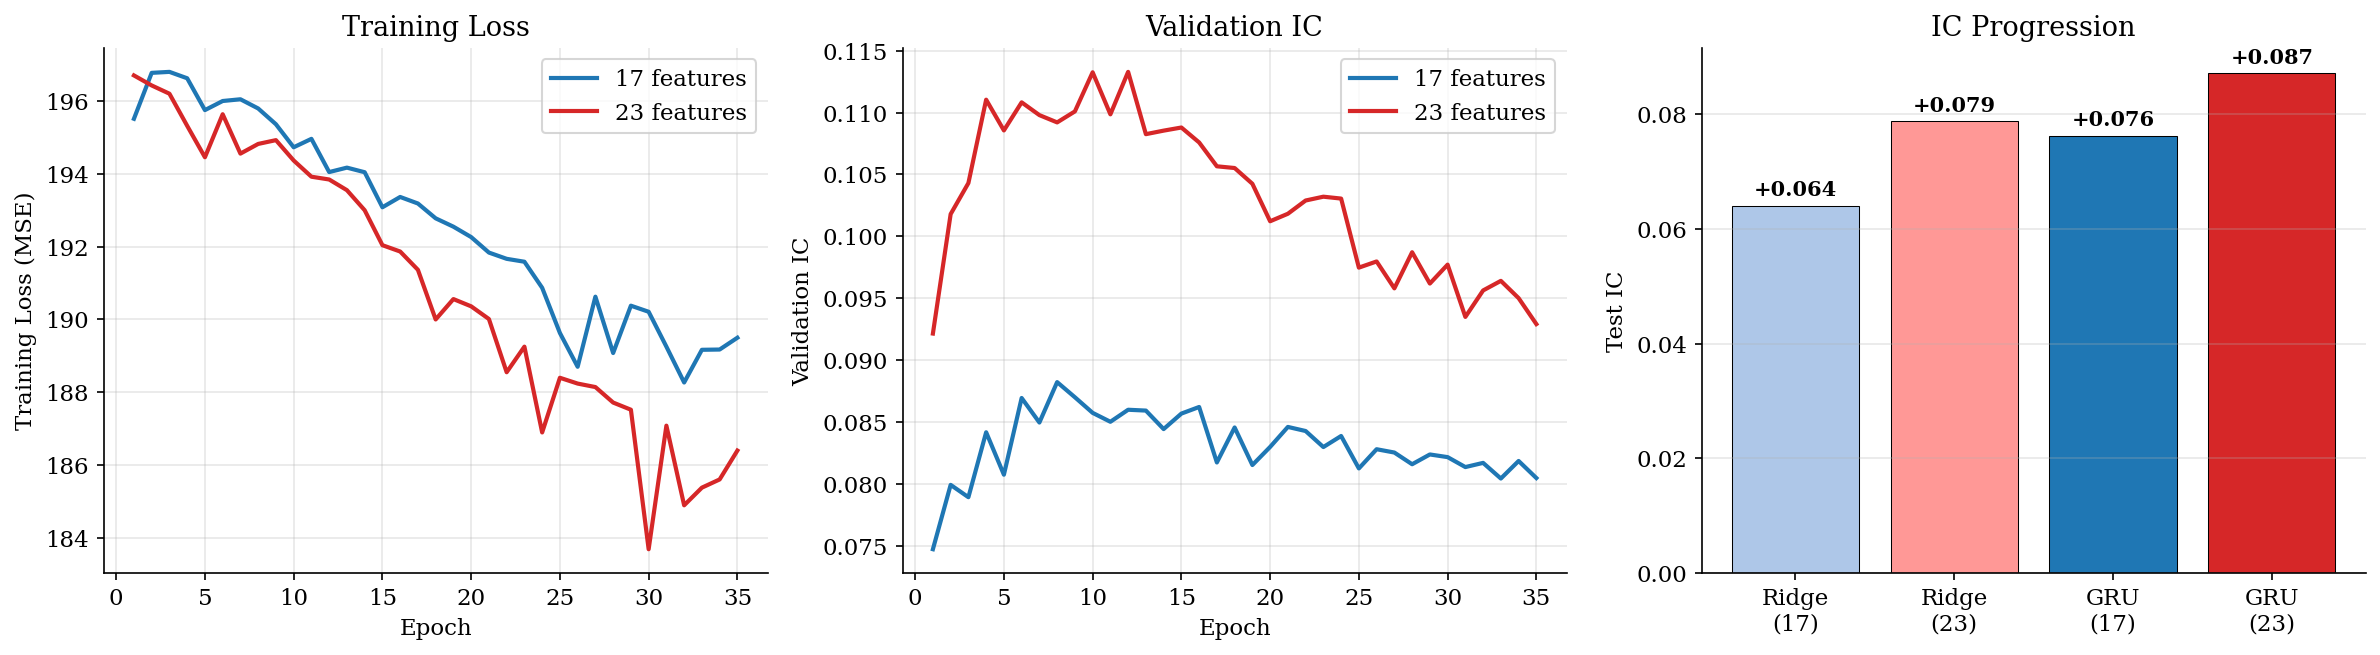

Saved fig5_gru_training


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(hist_orig['epoch'], hist_orig['train_loss'], color='#1f77b4', linewidth=2, label='17 features')
ax.plot(hist_full['epoch'], hist_full['train_loss'], color='#d62728', linewidth=2, label='23 features')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (MSE)')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hist_orig['epoch'], hist_orig['val_ic'], color='#1f77b4', linewidth=2, label='17 features')
ax.plot(hist_full['epoch'], hist_full['val_ic'], color='#d62728', linewidth=2, label='23 features')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation IC')
ax.set_title('Validation IC')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
models_x = ['Ridge\n(17)', 'Ridge\n(23)', 'GRU\n(17)', 'GRU\n(23)']
models_ic = [r_ro, r_rf, r_orig['ic'], r_full['ic']]
colors_bar = ['#aec7e8', '#ff9896', '#1f77b4', '#d62728']
bars = ax.bar(models_x, models_ic, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Test IC')
ax.set_title('IC Progression')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, models_ic):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:+.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig5_gru_training.png', dpi=200, bbox_inches='tight')
plt.savefig(OUT_DIR / 'fig5_gru_training.pdf', bbox_inches='tight')
plt.show()
print('Saved fig5_gru_training')